In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
visa_df=pd.read_csv("Visadataset.csv")
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [4]:
cat=visa_df.select_dtypes(include='str').columns.tolist()
num=visa_df.select_dtypes(exclude='str').columns.tolist()
cat,num

(['case_id',
  'continent',
  'education_of_employee',
  'has_job_experience',
  'requires_job_training',
  'region_of_employment',
  'unit_of_wage',
  'full_time_position',
  'case_status'],
 ['no_of_employees', 'yr_of_estab', 'prevailing_wage'])

- we did only a categorical column analysis
- we did only a numerical column analysis
- this time to do multiple column analysis
- lets assume continent vs casestatus
- we know different applicants from different continents
- in that some of visa are cretified,some are denied
- so visa cerified and denied overall info available in case_status

**np.where**

In [8]:
arr1=np.array([10,20,30,40,50])
result=np.where(arr1>25,99,arr1)
print(result)

[10 20 99 99 99]


In [15]:
con1 = visa_df['continent'] == 'Asia'
con2=visa_df['case_status']=='Certified'
certified=np.sum(con1&con2)
con3=visa_df['case_status']=='Denied'
denied=np.sum(con1&con3)
certified,denied

(np.int64(11012), np.int64(5849))

In [19]:
# con1 = visa_df['continent'] == 'Asia'
# con2=visa_df['case_status']=='Certified'
# con3=visa_df['case_status']=='Denied'
# certified=np.sum(con1&con2)
# denied=np.sum(con1&con3)
# certified,denied

status_class = ['Certified', 'Denied']
freq=[]
for i in status_class:
    con1 = visa_df['continent'] == 'Asia'
    con2=visa_df['case_status']==i
    freq.append(np.sum(con1&con2))
pd.DataFrame(zip(status_class,freq),columns=['status_class','Frequency'])

,status_class,Frequency
0,Certified,11012
1,Denied,5849


In [20]:
keys = visa_df['continent'].value_counts().keys()
clist,dlist=[],[]

for i in keys:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    con3 = visa_df['case_status'] == 'Denied'
    certi_count = np.sum(con1&con2)
    clist.append(certi_count)
    deni_count = np.sum(con1&con3)
    dlist.append(deni_count)
pd.DataFrame(zip(clist,dlist),columns=['certified','denied'],index = keys)

,certified,denied
continent,,
Asia,11012,5849
Europe,2957,775
North America,2037,1255
South America,493,359
Africa,397,154
Oceania,122,70


# crosstab:categorical vs categorical

In [23]:
#which column i want to choose as index
#which column i want to choose as column
#pd.crosstab(index,columns,)
pd.crosstab(visa_df['continent'],
            visa_df['case_status'])

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [24]:
pd.crosstab(visa_df['case_status'],visa_df['continent'])

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [26]:
con1 = visa_df['continent'] 
con2 = visa_df['case_status']
con3 = visa_df['education_of_employee'] 
pd.crosstab(con1,[con2,con3])

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

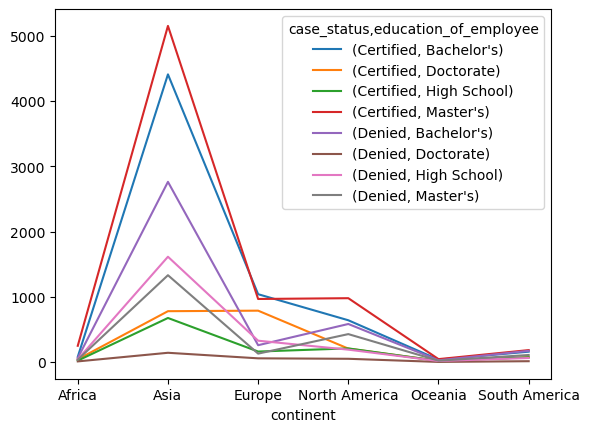

In [32]:
con1 = visa_df['continent'] 
con2 = visa_df['case_status']
con3 = visa_df['education_of_employee'] 
r2=pd.crosstab(con1,[con2,con3])
r2.plot()

<Axes: xlabel='continent'>

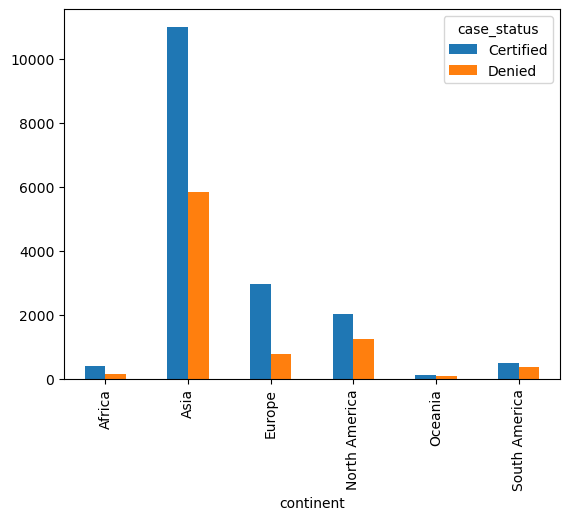

In [30]:
r1=pd.crosstab(visa_df['continent'],
            visa_df['case_status'])
r1.plot(kind='bar')

<Axes: xlabel='continent'>

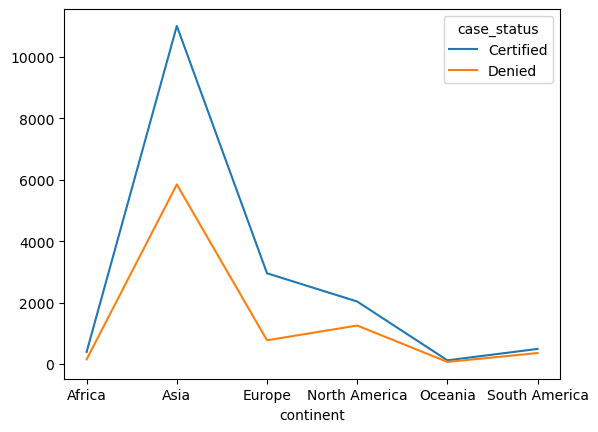

In [31]:
r1=pd.crosstab(visa_df['continent'],
            visa_df['case_status'])
r1.plot()

# Numerical vs Numerical

# scatter plot

- it is a graph representation between two numerical columns
- it is gives the relationship status between  two columns
    - postive or negative or no ralation

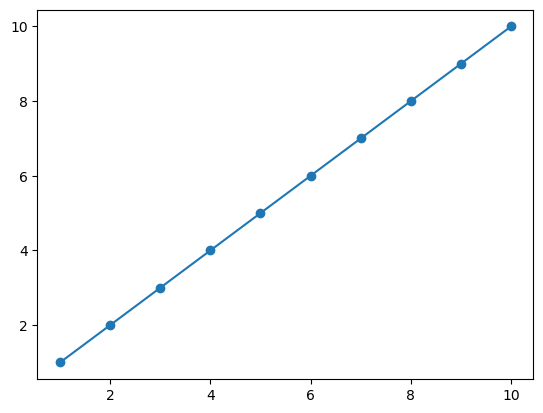

In [37]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

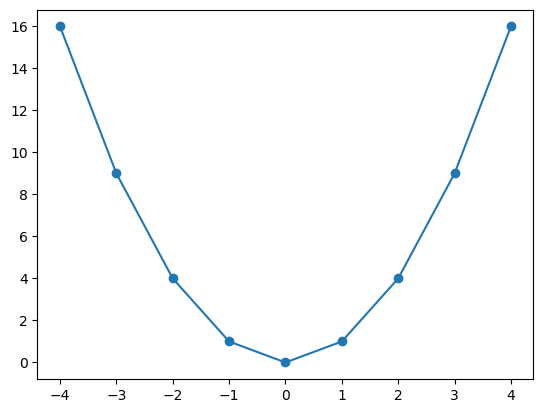

In [45]:
x=range(-4,5)
y=range(-4,5)
x_y=np.square(x)
plt.scatter(x,x_y)
plt.plot(x,x_y)
plt.show()






In [48]:
num

['no_of_employees', 'yr_of_estab', 'prevailing_wage']

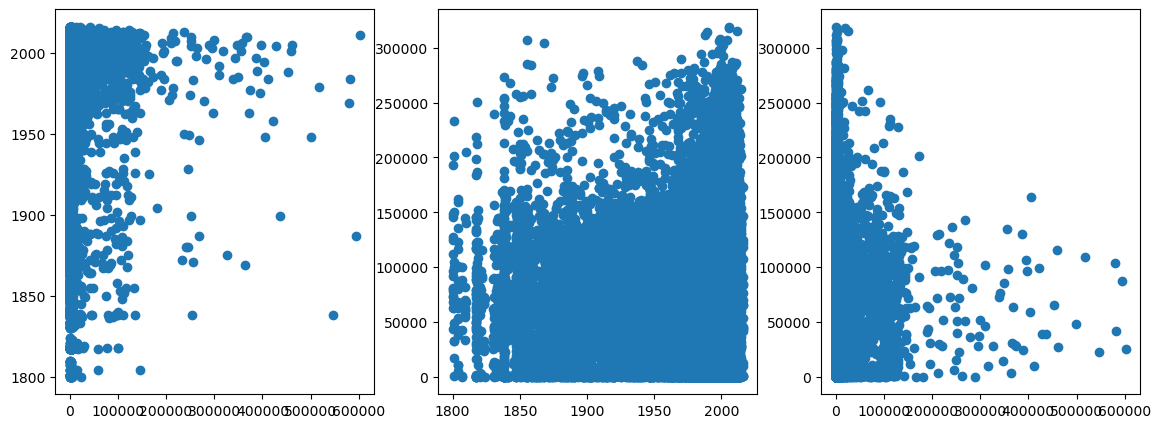

In [5]:
col1=visa_df['no_of_employees']
col2=visa_df[ 'yr_of_estab']
col3=visa_df[ 'prevailing_wage']
plt.figure(figsize=(14,5))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)


- we have draw the scatter plots for numerical columns
- by seeing above plots we are not able to indentify the relationship accuractly
- to get more confidence  will go to correlation matrix

In [9]:
# in your datafiles: winequality
# read the df
# perform the correlation matrix
# do you  ananlysis yourself immediately which columns has high =ve -ve relationship

In [15]:
wine_df = pd.read_csv("winequality_red.csv")
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
corr = wine_df.corr(numeric_only=True)

corr

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


**heatmap**

- so far what ever the plots we did the same we can impement by using seaborn 
- bar,countplots,histogram,distribution,boxplot


<Axes: >

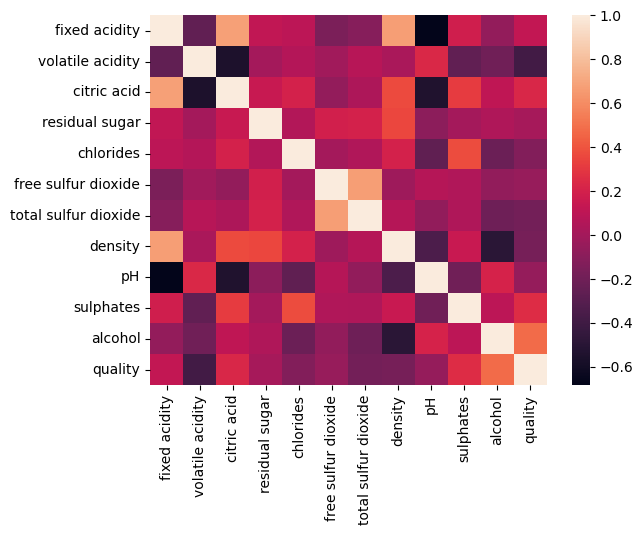

In [18]:
sns.heatmap(wine_df.corr())

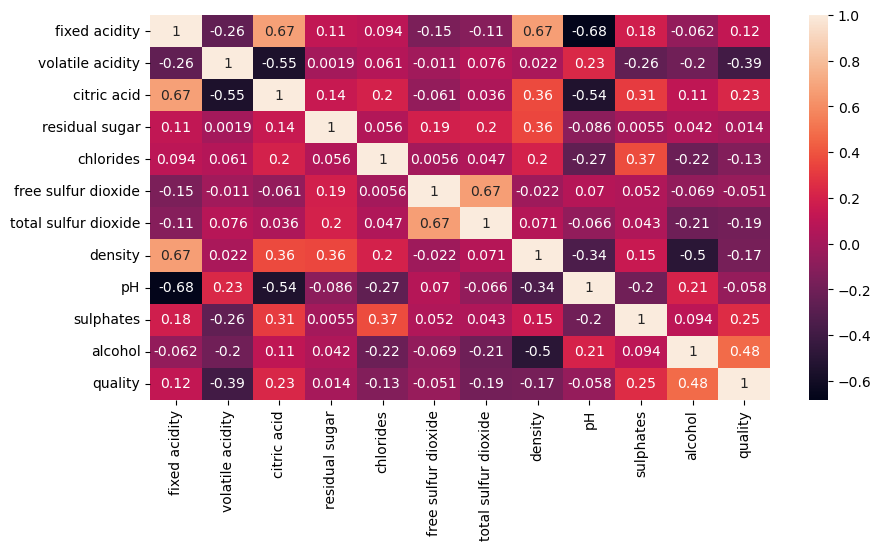

In [22]:
plt.figure(figsize=(10,5))
sns.heatmap(wine_df.corr(),
            annot=True)
plt.show()